In [1]:
import numpy as np
import torch
import pickle

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
## System parameters
M = 64 #Number of BS antennas
P = 1 #Power
K = 2 #Number of users
L = 8 #Number of pilots
Lp = [2,3,4,5,6,7,8]
B = 30 #Number of feedback bits per user

## Limited scattering channel parameters
LSF_UE = np.array([0.0,0.0],dtype=np.float32) #Mean of path gains for K users
Mainlobe_UE= np.array([0,0],dtype=np.float32) #Center of the AoD range for K users
HalfBW_UE = np.array([30.0,30.0],dtype=np.float32) #Half of the AoD range for K users

# SNR
snr_dl = 10 #SNR in dB
noise_std_dl = np.float32(np.sqrt(1/2)*np.sqrt(P/10**(snr_dl/10))) #STD of the Gaussian noise (per real dim.)

# Number of Monte-Carlo similations -> batch_size = N_experiment
iter = 10000

### Batch data 생성 함수

In [3]:
## 리스트 인덱싱은 [층, 행, 열], [행, 열]임!
def generate_batch_data(batch_size,M,K,
                        paths,#number of paths
                        LSF_UE #Mean of path gains for K users
                        ,Mainlobe_UE #Center of the AoD range for K users
                        ,HalfBW_UE #Half of the AoD range for K users
                        ):
    alphaR_input = np.zeros((batch_size,paths,K))
    alphaI_input = np.zeros((batch_size,paths,K))
    theta_input = np.zeros((batch_size,paths,K))
    for kk in range(K): # for the number of users
        alphaR_input[:,:,kk] = np.random.normal(loc=LSF_UE[kk], scale=1.0/np.sqrt(2), size=[batch_size,paths])
        alphaI_input[:,:,kk] = np.random.normal(loc=LSF_UE[kk], scale=1.0/np.sqrt(2), size=[batch_size,paths])
        theta_input[:,:,kk] = np.random.uniform(low=Mainlobe_UE[kk]-HalfBW_UE[kk], high=Mainlobe_UE[kk]+HalfBW_UE[kk], size=[batch_size,paths])
 
    #### Actual Channel
    from0toM = np.float64(np.arange(0, M, 1))
    alpha_act = alphaR_input + 1j*alphaI_input
    theta_act = (np.pi/180)*theta_input
    
    h_act = np.complex128(np.zeros((batch_size,M,K)))
    hR_act = np.float64(np.zeros((batch_size,M,K)))
    hI_act = np.float64(np.zeros((batch_size,M,K)))
    
    for kk in range(K):
        for ll in range(paths):
            theta_act_expanded_temp = np.tile(np.reshape(theta_act[:,ll,kk],[-1,1]),(1,M))
            response_temp = np.exp(1j*np.pi*np.multiply(np.sin(theta_act_expanded_temp),from0toM))
            alpha_temp = np.reshape(alpha_act[:,ll,kk],[-1,1])
            h_act[:,:,kk] += (1/np.sqrt(paths))*alpha_temp*response_temp
        hR_act[:,:,kk] = np.real(h_act[:,:,kk])
        hI_act[:,:,kk] = np.imag(h_act[:,:,kk])
        
    h_act = torch.tensor(h_act, dtype=torch.complex128).to(device)
    hR_act = torch.tensor(hR_act, dtype=torch.float64).to(device)
    hI_act = torch.tensor(hI_act, dtype=torch.float64).to(device)
    alphaR_act = torch.tensor(alphaR_input, dtype=torch.float64).to(device)
    alphaI_act = torch.tensor(alphaI_input, dtype=torch.float64).to(device)
    theta = torch.tensor(theta_input, dtype = torch.float64).to(device)
        
    return(h_act, hR_act, hI_act, alphaR_act, alphaI_act, theta)

In [4]:
def rate_calc(V, H_act, noise_std, K):
    hH_V = torch.bmm(H_act.mH, V)
    hH_V = torch.pow(abs(hH_V), 2)
    rate = torch.zeros(H_act.shape[0]).to(device)
    for kk in range(2):
        sig_pow = torch.sum(hH_V[:, kk, :], dim=-1)
        wanted_sig = hH_V[:, kk, kk]
        rate += torch.log2(1 + ( wanted_sig / (sig_pow - wanted_sig + 2 * noise_std ** 2)) )
    
    return torch.mean(rate)

In [5]:
with open("Lloyd-Max quantizer boundaries", 'rb') as fr:
    L_quantizer_boundary = pickle.load(fr)
with open("Lloyd-Max quantizer levels", 'rb') as fr:
    L_quantizer_level = pickle.load(fr)
with open("Uniform quantizer boundaries", 'rb') as fr:
    U_quantizer_boundary = pickle.load(fr)
with open("Uniform quantizer levels", 'rb') as fr:
    U_quantizer_level = pickle.load(fr)

In [6]:
def quantizer(R, I, T, Q_levels, L_bound, L_level, U_bound, U_level):
    Q_R = torch.zeros_like(R, dtype=torch.float64).to(device)
    Q_I = torch.zeros_like(I, dtype=torch.float64).to(device)
    Q_T = torch.zeros_like(T, dtype=torch.float64).to(device)
    
    for qq in range(Q_levels):
        ### condition for alpha_R
        if qq == 0:
            mask = (R <= L_bound[0])
        elif qq == Q_levels-1:
            mask = (R >= L_bound[qq-1])
        else:
            mask = (R <= L_bound[qq]) & (R >= L_bound[qq-1])
        Q_R[mask] = L_level[qq]
        
        ### condition for alpha_I
        if qq == 0:
            mask = (I <= L_bound[0])
        elif qq == Q_levels-1:
            mask = (I >= L_bound[qq-1])
        else:
            mask = (I <= L_bound[qq]) & (I >= L_bound[qq-1])
        Q_I[mask] = L_level[qq]
        
        ### condition for theta
        mask = (T <= U_bound[qq+1]) & (T >= U_bound[qq])
        Q_T[mask] = U_level[qq]
        
    return Q_R, Q_I, Q_T

In [20]:
rate_MRT, rate_ZF = {}, {}
K = 2 #Number of users
for ll in range(len(Lp)):
    paths = Lp[ll]
    h_act, _, _, alphaR, alphaI, theta = generate_batch_data(iter, M, K, paths, LSF_UE, Mainlobe_UE, HalfBW_UE)
    # alphaR, alphaI : (iter, Lp, K), theta : (iter, Lp, K)
    
    if (ll == 0) or ( ll == 3): # Lp=2 -> 5bit씩, Lp=5 -> 2bit씩
        Q_bit = int( 10 / paths )
        Q_level = 2 ** Q_bit
        Q_alphaR, Q_alphaI, Q_theta = quantizer(alphaR, alphaI, theta, Q_level, 
                                                L_quantizer_boundary[Q_level], L_quantizer_level[Q_level], U_quantizer_boundary[2**Q_bit], U_quantizer_level[2**Q_bit])
    elif ll == 1: # Lp=3 -> 4+4+2 bit
        alphaR_1 = alphaR[:, :2, :]
        alphaR_2 = alphaR[:, 2:, :]
        alphaI_1 = alphaI[:, :2, :]
        alphaI_2 = alphaI[:, 2:, :]
        theta_1 = theta[:, :2, :]
        theta_2 = theta[:, 2:, :]
        Q_bit_1 = 3
        Q_bit_2 = 4
  
        Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, 
                                                L_quantizer_boundary[2**Q_bit_1], L_quantizer_level[2**Q_bit_1], U_quantizer_boundary[2**Q_bit_1], U_quantizer_level[2**Q_bit_1])
        Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, 
                                                L_quantizer_boundary[2**Q_bit_2], L_quantizer_level[2**Q_bit_2], U_quantizer_boundary[2**Q_bit_2], U_quantizer_level[2**Q_bit_2])
        Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
        Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
        Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
        
    elif ll == 2: # Lp=4 -> 3*2 + 2*2 bit
        alphaR_1 = alphaR[:, :2, :]
        alphaR_2 = alphaR[:, 2:, :]
        alphaI_1 = alphaI[:, :2, :]
        alphaI_2 = alphaI[:, 2:, :]
        theta_1 = theta[:, :2, :]
        theta_2 = theta[:, 2:, :]
        Q_bit_1 = 3
        Q_bit_2 = 2
  
        Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, 
                                                L_quantizer_boundary[2**Q_bit_1], L_quantizer_level[2**Q_bit_1], U_quantizer_boundary[2**Q_bit_1], U_quantizer_level[2**Q_bit_1])
        Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, 
                                                L_quantizer_boundary[2**Q_bit_2], L_quantizer_level[2**Q_bit_2], U_quantizer_boundary[2**Q_bit_2], U_quantizer_level[2**Q_bit_2])
        Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
        Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
        Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
        
    elif ll == 4: # Lp=6 -> 1*2 + 2*4 bit
        alphaR_1 = alphaR[:, :2, :]
        alphaR_2 = alphaR[:, 2:, :]
        alphaI_1 = alphaI[:, :2, :]
        alphaI_2 = alphaI[:, 2:, :]
        theta_1 = theta[:, :2, :]
        theta_2 = theta[:, 2:, :]
        Q_bit_1 = 1
        Q_bit_2 = 2
  
        Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, 
                                                L_quantizer_boundary[2**Q_bit_1], L_quantizer_level[2**Q_bit_1], U_quantizer_boundary[2**Q_bit_1], U_quantizer_level[2**Q_bit_1])
        Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, 
                                                L_quantizer_boundary[2**Q_bit_2], L_quantizer_level[2**Q_bit_2], U_quantizer_boundary[2**Q_bit_2], U_quantizer_level[2**Q_bit_2])
        Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
        Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
        Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
        
    elif ll == 5: # Lp=7 -> 1*4 + 2*3 bit
        alphaR_1 = alphaR[:, :4, :]
        alphaR_2 = alphaR[:, 4:, :]
        alphaI_1 = alphaI[:, :4, :]
        alphaI_2 = alphaI[:, 4:, :]
        theta_1 = theta[:, :4, :]
        theta_2 = theta[:, 4:, :]
        Q_bit_1 = 1
        Q_bit_2 = 2
  
        Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, 
                                                L_quantizer_boundary[2**Q_bit_1], L_quantizer_level[2**Q_bit_1], U_quantizer_boundary[2**Q_bit_1], U_quantizer_level[2**Q_bit_1])
        Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, 
                                                L_quantizer_boundary[2**Q_bit_2], L_quantizer_level[2**Q_bit_2], U_quantizer_boundary[2**Q_bit_2], U_quantizer_level[2**Q_bit_2])
        Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
        Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
        Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
        
    else: # Lp=8 -> 1*6 + 2*2 bit
        alphaR_1 = alphaR[:, :6, :]
        alphaR_2 = alphaR[:, 6:, :]
        alphaI_1 = alphaI[:, :6, :]
        alphaI_2 = alphaI[:, 6:, :]
        theta_1 = theta[:, :6, :]
        theta_2 = theta[:, 6:, :]
        Q_bit_1 = 1
        Q_bit_2 = 2
  
        Q_alphaR_1, Q_alphaI_1, Q_theta_1 = quantizer(alphaR_1, alphaI_1, theta_1, 2**Q_bit_1, 
                                                L_quantizer_boundary[2**Q_bit_1], L_quantizer_level[2**Q_bit_1], U_quantizer_boundary[2**Q_bit_1], U_quantizer_level[2**Q_bit_1])
        Q_alphaR_2, Q_alphaI_2, Q_theta_2 = quantizer(alphaR_2, alphaI_2, theta_2, 2**Q_bit_2, 
                                                L_quantizer_boundary[2**Q_bit_2], L_quantizer_level[2**Q_bit_2], U_quantizer_boundary[2**Q_bit_2], U_quantizer_level[2**Q_bit_2])
        Q_alphaR = torch.cat((Q_alphaR_1, Q_alphaR_2), dim=1)
        Q_alphaI = torch.cat((Q_alphaI_1, Q_alphaI_2), dim=1)
        Q_theta = torch.cat((Q_theta_1, Q_theta_2), dim=1)
        
    Q_h = torch.zeros_like(h_act, dtype=torch.complex128).to(device) # (batch, M, K)
    from0toM = torch.arange(0, M, 1, dtype=torch.float64).to(device)
    Q_alpha = torch.complex(Q_alphaR, Q_alphaI).to(device)
    Q_theta = (torch.pi/180) * Q_theta
    
    for kk in range(2):
        for ii in range(paths):
            Q_theta_expended_temp = Q_theta[:, ii, kk].unsqueeze(1).repeat(1,M)
            Q_response_temp = torch.exp(1j * torch.pi * (torch.sin(Q_theta_expended_temp) * from0toM))
            Q_alpha_temp = Q_alpha[:, ii, kk].unsqueeze(1)
            Q_h[:, :, kk] += (1/ torch.sqrt(torch.tensor(paths))) *(Q_response_temp * Q_alpha_temp)
            
    V_MRT = Q_h
    V_MRT = V_MRT / torch.sqrt(torch.einsum('bii->b', torch.bmm(V_MRT.mH , V_MRT))).unsqueeze(1).unsqueeze(2)
    rate_MRT[paths] = rate_calc(V_MRT, h_act, noise_std_dl, K).item()
    
    V_ZF = torch.linalg.pinv(Q_h.mH) # (batch, M, K)
    V_ZF = V_ZF / torch.sqrt(torch.einsum('bii->b', torch.bmm(V_ZF.mH , V_ZF))).unsqueeze(1).unsqueeze(2)
    rate_ZF[paths] = rate_calc(V_ZF, h_act, noise_std_dl, K).item()

In [10]:
print(rate_ZF)
print(rate_MRT)

{2: 11.91513729095459, 3: 6.411228656768799, 4: 4.092200756072998, 5: 2.7369492053985596, 6: 2.6174206733703613, 7: 2.4045636653900146, 8: 2.2724082469940186}
{2: 11.750091552734375, 3: 6.718337535858154, 4: 4.372032642364502, 5: 2.869036912918091, 6: 2.72935152053833, 7: 2.504753589630127, 8: 2.341996192932129}


In [11]:
rate_MRT_equalbit, rate_ZF_equalbit = {}, {}
K = 2 #Number of users
for ll in range(len(Lp)):
    paths = Lp[ll]
    h_act, _, _, alphaR, alphaI, theta = generate_batch_data(iter, M, K, paths, LSF_UE, Mainlobe_UE, HalfBW_UE)
    Q_level = 2 ** 5
    Q_alphaR, Q_alphaI, Q_theta = quantizer(alphaR, alphaI, theta, Q_level, 
                                                L_quantizer_boundary[Q_level], L_quantizer_level[Q_level], U_quantizer_boundary[Q_level], U_quantizer_level[Q_level])
    Q_h = torch.zeros_like(h_act, dtype=torch.complex128).to(device) # (batch, M, K)
    from0toM = torch.arange(0, M, 1, dtype=torch.float64).to(device)
    Q_alpha = torch.complex(Q_alphaR, Q_alphaI).to(device)
    Q_theta = (torch.pi/180) * Q_theta
    
    for kk in range(2):
        for ii in range(paths):
            Q_theta_expended_temp = Q_theta[:, ii, kk].unsqueeze(1).repeat(1,M)
            Q_response_temp = torch.exp(1j * torch.pi * (torch.sin(Q_theta_expended_temp) * from0toM))
            Q_alpha_temp = Q_alpha[:, ii, kk].unsqueeze(1)
            Q_h[:, :, kk] += (1/ torch.sqrt(torch.tensor(paths))) * (Q_response_temp * Q_alpha_temp)
            
    V_MRT = Q_h
    V_MRT = V_MRT / torch.sqrt(torch.real(torch.einsum('bii->b', torch.bmm(V_MRT.mH , V_MRT)))).unsqueeze(1).unsqueeze(2)
    rate_MRT_equalbit[paths] = rate_calc(V_MRT, h_act, noise_std_dl, K ).item()
    
    V_ZF = torch.linalg.pinv(Q_h.mH) # (batch, M, K)
    V_ZF = V_ZF / torch.sqrt(torch.real(torch.einsum('bii->b', torch.bmm(V_ZF.mH , V_ZF)))).unsqueeze(1).unsqueeze(2)
    rate_ZF_equalbit[paths] = rate_calc(V_ZF, h_act, noise_std_dl ,K).item()

In [15]:
print(rate_ZF_equalbit)
print(rate_MRT_equalbit)

{2: 11.87509536743164, 3: 11.294005393981934, 4: 10.839983940124512, 5: 10.474281311035156, 6: 10.170035362243652, 7: 10.060619354248047, 8: 9.875802993774414}
{2: 11.709726333618164, 3: 10.884572982788086, 4: 10.235979080200195, 5: 9.750813484191895, 6: 9.379240036010742, 7: 9.181952476501465, 8: 9.014653205871582}


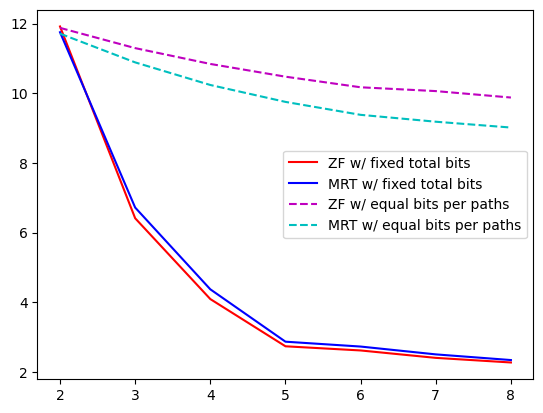

In [14]:
import matplotlib.pyplot as plt

plt.plot(Lp, rate_ZF.values(), '-r', label = 'ZF w/ fixed total bits')
plt.plot(Lp, rate_MRT.values(), '-b', label ='MRT w/ fixed total bits')
plt.plot(Lp, rate_ZF_equalbit.values(), '--m', label ='ZF w/ equal bits per paths')
plt.plot(Lp, rate_MRT_equalbit.values(), '--c', label ='MRT w/ equal bits per paths')

plt.legend()

In [17]:
with open('ZF full CSIR', 'wb') as ff:
    pickle.dump(list(rate_ZF.values()), ff)
with open('MRT full CSIR', 'wb') as ff:
    pickle.dump(list(rate_MRT.values()), ff)